# Iterations Summary Analysis

This notebook analyzes the rows written by `julia/scripts/main_iterator.jl` in `experiments/iterations_summary.csv`.
It groups runs by batch prefix, lists the n/beta combinations present in each batch, and flags batches that are complete in the sense that every expected n_qubits x beta pair appears at least once.

In [2]:
from pathlib import Path
import math
import re
import tomllib
import json

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
CANDIDATE_ROOTS = [NOTEBOOK_DIR, NOTEBOOK_DIR.parent]

PLOTS_LAYOUT = [
    ["amplitude_damping", "phase_damping"],
    ["phase_damping", "amplitude_damping"],
    ["bitflip", "amplitude_damping"],
    ["amplitude_damping", "bitflip"],
    ["amplitude_damping", "general"],
    ["general", "amplitude_damping"],
    ["general", "general"],
]

PROJECT_ROOT = NOTEBOOK_DIR.parent
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
SUMMARY_CSV = EXPERIMENTS_DIR / "iterations_summary.csv"

## One Qubit Simulations

In [3]:
def batch_prefix(name: str) -> str:
    return re.sub(r"n\d+_b\d+(?:_.*)?$", "", name)


def normalize_bool(value) -> bool:
    if isinstance(value, bool):
        return value
    if value is None:
        return False
    if isinstance(value, float) and math.isnan(value):
        return False
    if isinstance(value, (int, float)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def noise_name_from_option(option):
    if isinstance(option, (list, tuple)) and len(option) >= 2:
        return option[1]
    return None


def other_noise_from_options(noise_options, real_noise: str | None) -> str | None:
    noise_names = [noise_name_from_option(option) for option in noise_options]
    noise_names = [noise_name for noise_name in noise_names if noise_name]
    for noise_name in noise_names:
        if noise_name != real_noise:
            return noise_name
    return noise_names[0] if noise_names else None


def infer_other_noise(row: pd.Series) -> str | None:
    real_noise = row.get("real_noise")
    for column in ["noise_1_name", "noise_2_name"]:
        noise_name = row.get(column)
        if pd.notna(noise_name) and noise_name != real_noise:
            return noise_name
    return row.get("noise_1_name") if pd.notna(row.get("noise_1_name")) else None


def read_config_metadata(experiments_dir: Path, experiment_name: str) -> dict:
    config_path = experiments_dir / experiment_name / "config.toml"
    metadata = {
        "config_path": config_path,
        "config_exists": config_path.exists(),
        "config_correlated_noise": None,
        "config_real_noise": None,
        "config_other_noise": None,
        "config_noise_1_name": None,
        "config_noise_2_name": None,
    }
    if not metadata["config_exists"]:
        return metadata

    with config_path.open("rb") as handle:
        config = tomllib.load(handle)

    noise_options = config.get("noise_options", [])
    real_noise = config.get("real_noise")
    metadata.update(
        {
            "config_correlated_noise": normalize_bool(config.get("correlated_noise")),
            "config_real_noise": real_noise,
            "config_other_noise": other_noise_from_options(noise_options, real_noise),
            "config_noise_1_name": noise_name_from_option(noise_options[0]) if len(noise_options) > 0 else None,
            "config_noise_2_name": noise_name_from_option(noise_options[1]) if len(noise_options) > 1 else None,
        }
    )
    return metadata



In [4]:
experiments_names = [
  "1qbt_rand_amp_auto",
  "1qbt_btfp_amp_auto",
  "1qbt_amp_phs_auto",
  "1qbt_rand_rand_auto"
]

for folder in experiments_names:
    print(f"Processing {folder}...")
    experiment_dir = EXPERIMENTS_DIR / folder

    config = read_config_metadata(EXPERIMENTS_DIR, folder)
    try:
      with open(EXPERIMENTS_DIR / folder / "data" / "results.json", "r") as f:
          results = json.load(f)
    except FileNotFoundError:
      print(f"Results file not found for {folder}. Skipping.")
    

Processing 1qbt_rand_amp_auto...
Processing 1qbt_btfp_amp_auto...
Processing 1qbt_amp_phs_auto...
Results file not found for 1qbt_amp_phs_auto. Skipping.
Processing 1qbt_rand_rand_auto...


In [40]:

def config_metadata_discrepancies(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    checks = [
        ("correlated_noise", "csv_correlated_noise", "config_correlated_noise"),
        ("real_noise", "csv_real_noise", "config_real_noise"),
        ("noise_1_name", "csv_noise_1_name", "config_noise_1_name"),
        ("noise_2_name", "csv_noise_2_name", "config_noise_2_name"),
    ]
    for _, row in frame.loc[frame["config_exists"]].iterrows():
        for field, csv_col, config_col in checks:
            csv_value = row.get(csv_col)
            config_value = row.get(config_col)
            if pd.isna(config_value) or csv_value == config_value:
                continue
            rows.append(
                {
                    "name": row["name"],
                    "field": field,
                    "csv_value": csv_value,
                    "config_value": config_value,
                    "config_path": row["config_path"],
                }
            )
    return pd.DataFrame(rows)


def load_summary_frame(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    frame["batch"] = frame["name"].map(batch_prefix)
    frame["n_qubits"] = frame["n_qubits"].astype(int)
    frame["beta"] = frame["beta"].astype(float)
    frame["avg_fidelity"] = frame["avg_fidelity"].astype(float)
    frame["infidelity"] = 1.0 - frame["avg_fidelity"]

    frame["csv_correlated_noise"] = frame["correlated_noise"].map(normalize_bool)
    frame["csv_real_noise"] = frame["real_noise"]
    frame["csv_noise_1_name"] = frame["noise_1_name"]
    frame["csv_noise_2_name"] = frame["noise_2_name"]

    config_frame = pd.DataFrame(
        [read_config_metadata(path.parent, experiment_name) for experiment_name in frame["name"]]
    )
    frame = pd.concat([frame.reset_index(drop=True), config_frame], axis=1)

    config_mask = frame["config_exists"]
    frame["correlated_noise"] = frame["csv_correlated_noise"]
    frame.loc[config_mask, "correlated_noise"] = frame.loc[config_mask, "config_correlated_noise"]
    frame.loc[config_mask, "real_noise"] = frame.loc[config_mask, "config_real_noise"]
    frame.loc[config_mask, "noise_1_name"] = frame.loc[config_mask, "config_noise_1_name"]
    frame.loc[config_mask, "noise_2_name"] = frame.loc[config_mask, "config_noise_2_name"]
    frame["other_noise"] = frame["config_other_noise"]
    frame.loc[~config_mask, "other_noise"] = frame.loc[~config_mask].apply(infer_other_noise, axis=1)
    return frame


def summarize_batches(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for batch, group in frame.groupby("batch", sort=True):
        n_values = sorted(group["n_qubits"].unique().tolist())
        beta_values = sorted(group["beta"].unique().tolist())
        combo_frame = group[["n_qubits", "beta"]].drop_duplicates()
        observed = set(map(tuple, combo_frame.to_numpy()))
        expected = {(n, beta) for n in n_values for beta in beta_values}
        missing = sorted(expected - observed)

        rows.append(
            {
                "batch": batch,
                "rows": len(group),
                "unique_combos": len(observed),
                "expected_combos": len(expected),
                "complete": not missing,
                "n_qubits": n_values,
                "betas": beta_values,
                "missing_combos": missing,
            }
        )

    return pd.DataFrame(rows).sort_values("batch").reset_index(drop=True)


def get_noise_name(name: str, correlated: bool) -> str:
    str_name = ""
    if correlated:
        str_name += "Correlated "
    else:
        str_name += "Uncorrelated "
    str_name += (" ".join(name.split("_")))
    str_name += " noise"
    return str_name


In [6]:
summary_df = load_summary_frame(SUMMARY_CSV)
summary_df = summary_df.sort_values(["batch", "n_qubits", "beta", "name"]).reset_index(drop=True)
metadata_issues_df = config_metadata_discrepancies(summary_df)

if metadata_issues_df.empty:
    print("Config metadata check: no CSV/config mismatches found.")
else:
    print(f"Config metadata check: found {len(metadata_issues_df)} CSV/config mismatches; using config values downstream.")
    display(metadata_issues_df)

summary_df


Config metadata check: found 33 CSV/config mismatches; using config values downstream.


,name,field,csv_value,config_value,config_path
0,20261306_rand_amp_n2_b01,correlated_noise,True,False,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...
1,20261306_rand_amp_n2_b01,real_noise,amplitude_damping,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...
2,20261306_rand_amp_n2_b01,real_noise,amplitude_damping,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...
3,20261306_rand_amp_n2_b05,correlated_noise,True,False,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...
4,20261306_rand_amp_n2_b05,real_noise,amplitude_damping,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...
5,20261306_rand_amp_n2_b05,real_noise,amplitude_damping,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...
6,20261306_rand_amp_n2_b10,correlated_noise,True,False,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...
7,20261306_rand_amp_n2_b10,real_noise,amplitude_damping,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...
8,20261306_rand_amp_n2_b10,real_noise,amplitude_damping,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...
9,20261306_rand_amp_n2_b15,correlated_noise,True,False,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...


,name,n_qubits,beta,dt,n_timesteps,n_states,starting_state,recovery_type,collision_unitary,ancilla_state,...,csv_noise_1_name,csv_noise_2_name,config_path,config_exists,config_correlated_noise,config_real_noise,config_other_noise,config_noise_1_name,config_noise_2_name,other_noise
0,20261106_amp_btfp_corr_n2_b01,2,0.1,0.314159,8,100,thermal,codespace,jc,ground_qubit,...,amplitude_damping,bitflip,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,False,None,NaN,NaN,NaN,NaN,bitflip
1,20261106_amp_btfp_corr_n2_b10,2,1.0,0.314159,8,100,thermal,codespace,jc,ground_qubit,...,amplitude_damping,bitflip,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,False,None,NaN,NaN,NaN,NaN,bitflip
2,20261106_amp_btfp_corr_n2_b20,2,2.0,0.314159,8,100,thermal,codespace,jc,ground_qubit,...,amplitude_damping,bitflip,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,False,None,NaN,NaN,NaN,NaN,bitflip
3,20261106_amp_btfp_corr_n2_b50,2,5.0,0.314159,8,100,thermal,codespace,jc,ground_qubit,...,amplitude_damping,bitflip,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,False,None,NaN,NaN,NaN,NaN,bitflip
4,20261106_amp_btfp_corr_n3_b01,3,0.1,0.314159,8,100,thermal,codespace,jc,ground_qubit,...,amplitude_damping,bitflip,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,False,None,NaN,NaN,NaN,NaN,bitflip
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,20261506_amp_phs_corr_n3_b05,3,0.5,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,amplitude_damping,phase_damping,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,amplitude_damping,phase_damping,amplitude_damping,phase_damping,phase_damping
306,20261506_amp_phs_corr_n3_b10,3,1.0,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,amplitude_damping,phase_damping,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,amplitude_damping,phase_damping,amplitude_damping,phase_damping,phase_damping
307,20261506_amp_phs_corr_n3_b15,3,1.5,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,amplitude_damping,phase_damping,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,amplitude_damping,phase_damping,amplitude_damping,phase_damping,phase_damping
308,20261506_amp_phs_corr_n3_b20,3,2.0,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,amplitude_damping,phase_damping,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,amplitude_damping,phase_damping,amplitude_damping,phase_damping,phase_damping


In [7]:
# Remove old simulations
summary_df = summary_df[~summary_df['name'].str.contains("20261106")]

In [8]:
# pd.read_csv(SUMMARY_CSV)
summary_df[summary_df["name"].str.contains("20261306_rand_rand")]

,name,n_qubits,beta,dt,n_timesteps,n_states,starting_state,recovery_type,collision_unitary,ancilla_state,...,csv_noise_1_name,csv_noise_2_name,config_path,config_exists,config_correlated_noise,config_real_noise,config_other_noise,config_noise_1_name,config_noise_2_name,other_noise
239,20261306_rand_rand_n2_b01,2,0.1,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
240,20261306_rand_rand_n2_b05,2,0.5,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
241,20261306_rand_rand_n2_b10,2,1.0,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
242,20261306_rand_rand_n2_b15,2,1.5,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
243,20261306_rand_rand_n2_b20,2,2.0,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
244,20261306_rand_rand_n2_b25,2,2.5,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
245,20261306_rand_rand_n3_b01,3,0.1,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
246,20261306_rand_rand_n3_b05,3,0.5,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
247,20261306_rand_rand_n3_b10,3,1.0,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general
248,20261306_rand_rand_n3_b15,3,1.5,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,general,general,general,general


In [9]:

batch_summary_df = summarize_batches(summary_df)
complete_batches_df = batch_summary_df.loc[batch_summary_df["complete"]].copy()
incomplete_batches_df = batch_summary_df.loc[~batch_summary_df["complete"]].copy()

print("Complete batches:")
display(complete_batches_df[["batch", "rows", "unique_combos", "n_qubits", "betas"]])

print("\nIncomplete batches and missing combinations:")
display(incomplete_batches_df[["batch", "unique_combos", "expected_combos", "missing_combos"]])

print("\nFull batch summary:")
display(batch_summary_df)


Complete batches:


,batch,rows,unique_combos,n_qubits,betas
1,20261206_amp_phs_corr_,5,5,[4],"[0.1, 0.5, 1.0, 1.5, 2.0]"
3,20261306_amp_general_,18,18,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]"
4,20261306_amp_phs_,18,18,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]"
9,20261306_rand_amp_corr,18,18,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]"
10,20261306_rand_amp_corr_,18,18,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]"
11,20261306_rand_rand_,24,18,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]"
12,20261306_rand_rand_corr,18,18,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]"
14,20261506_amp_phs_corr_,12,12,"[2, 3]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]"



Incomplete batches and missing combinations:


,batch,unique_combos,expected_combos,missing_combos
0,20261206_amp_btfp_corr_,17,18,"[(4, 2.5)]"
2,20261206_btfp_amp_corr_,17,18,"[(4, 2.5)]"
5,20261306_amp_phs_corr_,17,18,"[(4, 2.5)]"
6,20261306_phs_amp_,17,18,"[(4, 2.5)]"
7,20261306_phs_amp_corr_,17,18,"[(4, 2.5)]"
8,20261306_rand_amp_,17,18,"[(4, 0.1)]"
13,20261506_amp_btfp,17,18,"[(4, 2.5)]"



Full batch summary:


,batch,rows,unique_combos,expected_combos,complete,n_qubits,betas,missing_combos
0,20261206_amp_btfp_corr_,17,17,18,False,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]","[(4, 2.5)]"
1,20261206_amp_phs_corr_,5,5,5,True,[4],"[0.1, 0.5, 1.0, 1.5, 2.0]",[]
2,20261206_btfp_amp_corr_,17,17,18,False,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]","[(4, 2.5)]"
3,20261306_amp_general_,18,18,18,True,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]",[]
4,20261306_amp_phs_,18,18,18,True,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]",[]
5,20261306_amp_phs_corr_,17,17,18,False,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]","[(4, 2.5)]"
6,20261306_phs_amp_,17,17,18,False,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]","[(4, 2.5)]"
7,20261306_phs_amp_corr_,17,17,18,False,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]","[(4, 2.5)]"
8,20261306_rand_amp_,42,17,18,False,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]","[(4, 0.1)]"
9,20261306_rand_amp_corr,18,18,18,True,"[2, 3, 4]","[0.1, 0.5, 1.0, 1.5, 2.0, 2.5]",[]


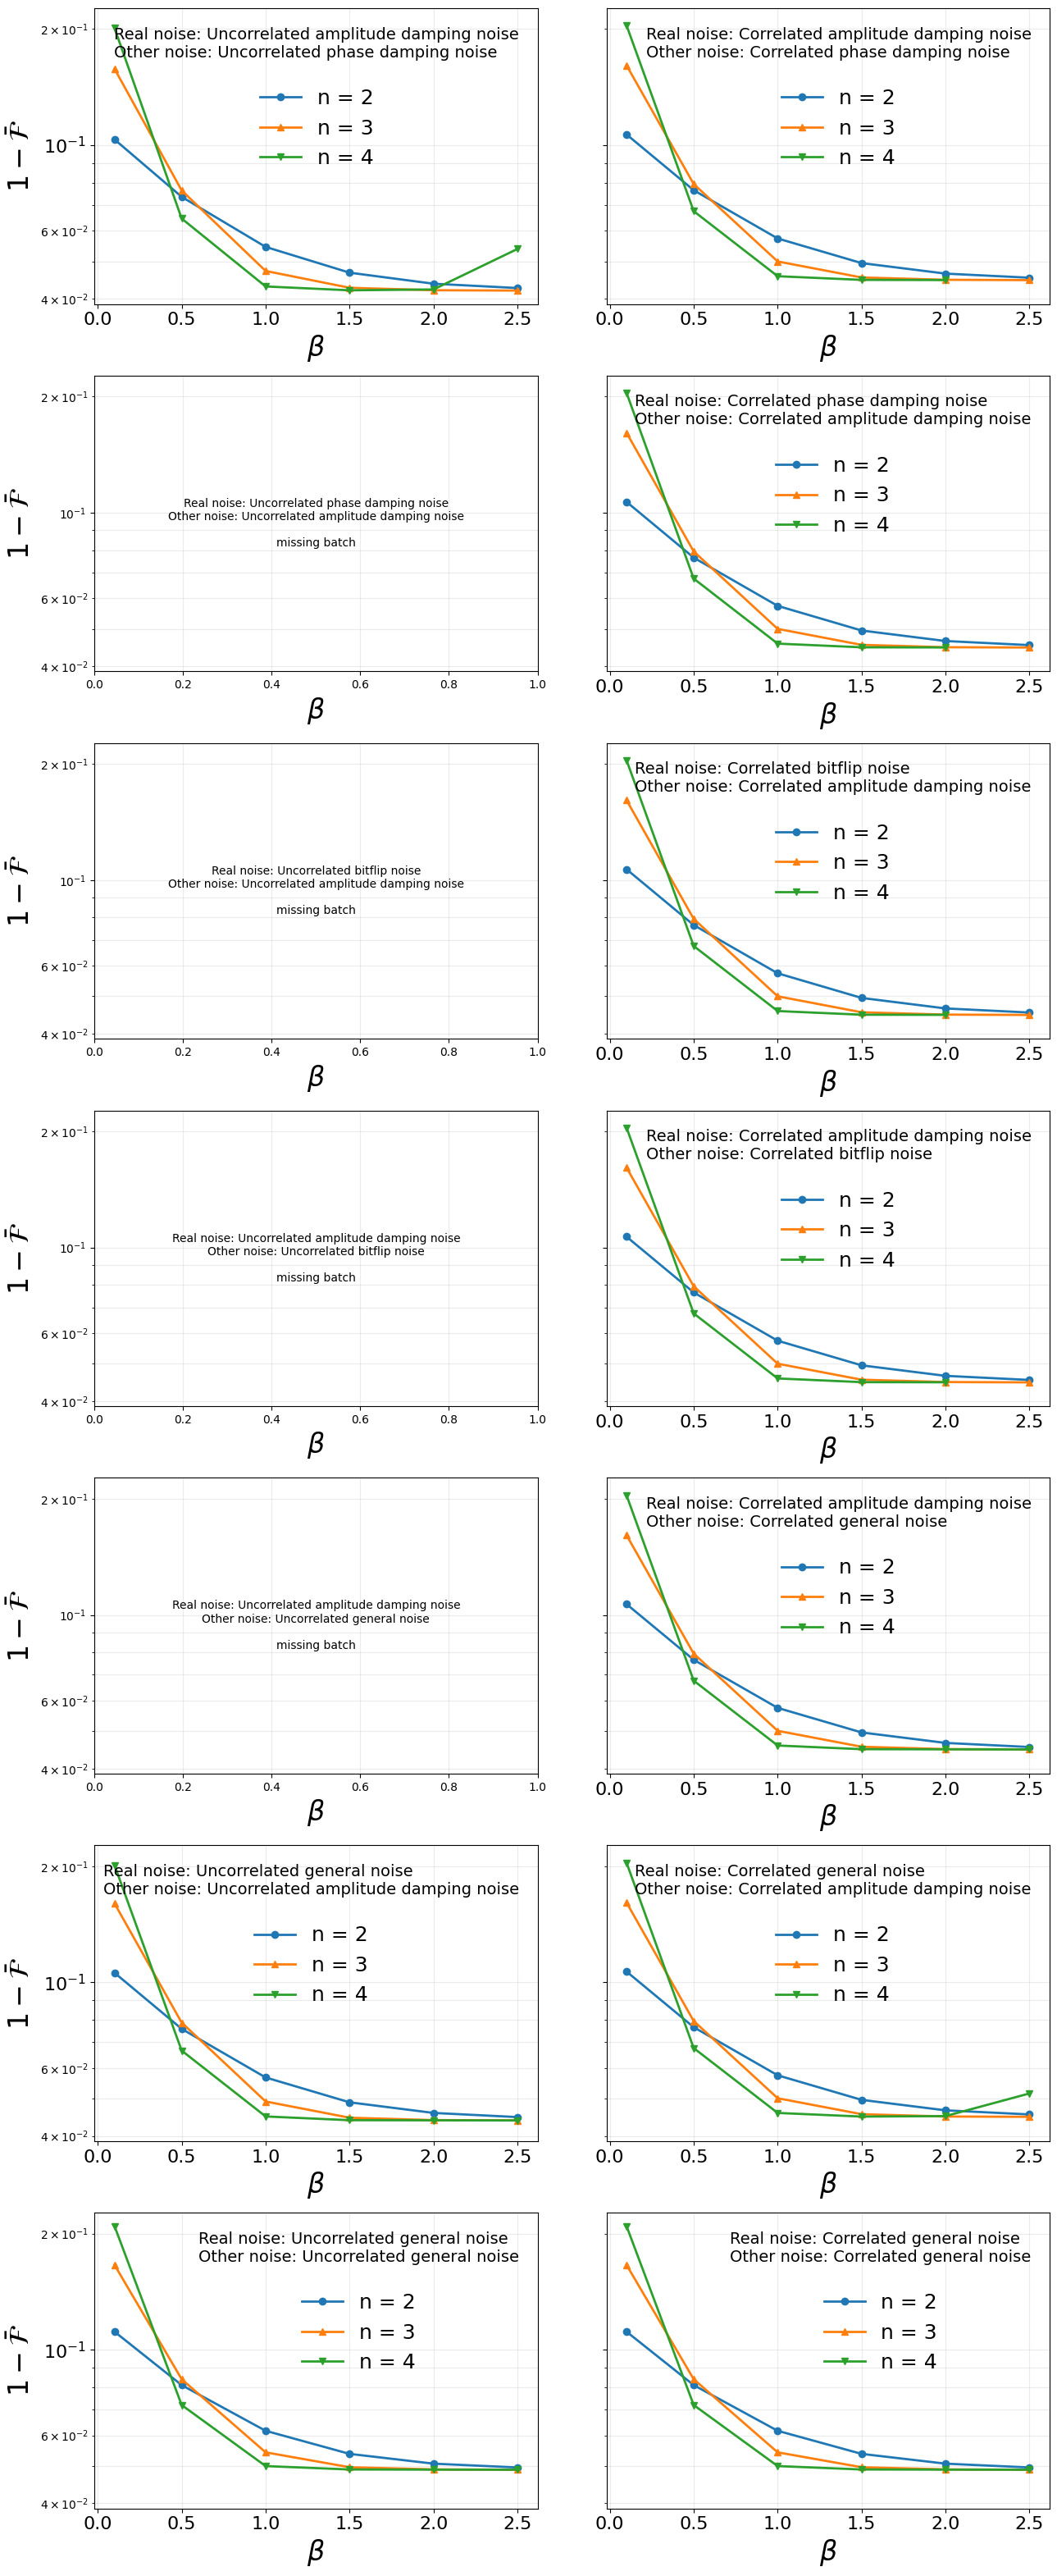

In [46]:
def add_layout_columns(frame: pd.DataFrame, *, batch_col: str) -> pd.DataFrame:
    prepared = frame.copy()
    if "other_noise" not in prepared.columns:
        prepared["other_noise"] = prepared.apply(infer_other_noise, axis=1)
    else:
        missing_other_noise = prepared["other_noise"].isna()
        prepared.loc[missing_other_noise, "other_noise"] = prepared.loc[missing_other_noise].apply(
            infer_other_noise, axis=1
        )

    prepared["layout_noise_1"] = prepared["real_noise"]
    prepared["layout_noise_2"] = prepared["other_noise"]
    prepared["layout_correlation"] = prepared["correlated_noise"].map(normalize_bool)
    return prepared


def plot_batch_grid(
    frame: pd.DataFrame,
    *,
    layout: list[list[str]] | None = None,
    batch_col: str = "batch",
    n_col: str = "n_qubits",
    beta_col: str = "beta",
    fidelity_col: str = "avg_fidelity",
    figsize_per_plot: tuple[float, float] = (6.5, 4.5),
    log_scale: bool = True,
    show: bool = True,
):
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0", "C1", "C2", "C3"])
    markers = ["o", "^", "v", "<", ">", "s", "D", "P", "X"]

    prepared = add_layout_columns(frame, batch_col=batch_col)
    selected_layout = layout or PLOTS_LAYOUT
    n_rows = len(selected_layout)
    n_cols = 2
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows),
        squeeze=False,
        sharey=True,
    )

    for row_index, (noise_1, noise_2) in enumerate(selected_layout):
        for col_index, correlated in enumerate([False, True]):
            ax = axes[row_index][col_index]
            slot_frame = prepared.loc[
                (prepared["layout_noise_1"] == noise_1)
                & (prepared["layout_noise_2"] == noise_2)
                & (prepared["layout_correlation"] == correlated),
                [batch_col, n_col, beta_col, fidelity_col],
            ].copy()

            legend_title = (
                f"Real noise: {get_noise_name(noise_1, correlated)}\n"
                f"Other noise: {get_noise_name(noise_2, correlated)}\n"
            )
            ax.set_xlabel(r"$\beta$", fontsize=24)
            if col_index == 0:
                ax.set_ylabel(r"$1 - \bar{\mathcal{F}}$", fontsize=24)
            ax.grid(True, which="both", alpha=0.25)

            if slot_frame.empty:
                ax.text(
                    0.5,
                    0.5,
                    f"{legend_title}\nmissing batch",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                continue

            slot_frame["infidelity"] = 1.0 - slot_frame[fidelity_col]
            plot_frame = (
                slot_frame.groupby([n_col, beta_col], as_index=False, sort=True)["infidelity"]
                .mean()
                .sort_values([n_col, beta_col])
            )

            n_values = sorted(plot_frame[n_col].unique().tolist())
            for i, n_value in enumerate(n_values):
                subset = plot_frame.loc[plot_frame[n_col] == n_value].sort_values(beta_col)
                ax.plot(
                    subset[beta_col],
                    subset["infidelity"],
                    marker=markers[i % len(markers)],
                    linewidth=2,
                    color=colors[i % len(colors)],
                    label=f"n = {n_value}",
                )

            if log_scale:
                ax.set_yscale("log")
            ax.legend(frameon=False, title=legend_title, title_fontsize=14, fontsize=18)
            ax.tick_params(axis="both", which="major", labelsize=16)

    fig.tight_layout()
    if show:
        plt.show()
    return fig, axes


fig_comparison, axes = plot_batch_grid(
    summary_df,
    layout=PLOTS_LAYOUT,
    log_scale=True,
)

fig_comparison.savefig(EXPERIMENTS_DIR / "comparison_grid_all.png", dpi=300)
fig_comparison.savefig(EXPERIMENTS_DIR / "comparison_grid_all.pdf", dpi=300)



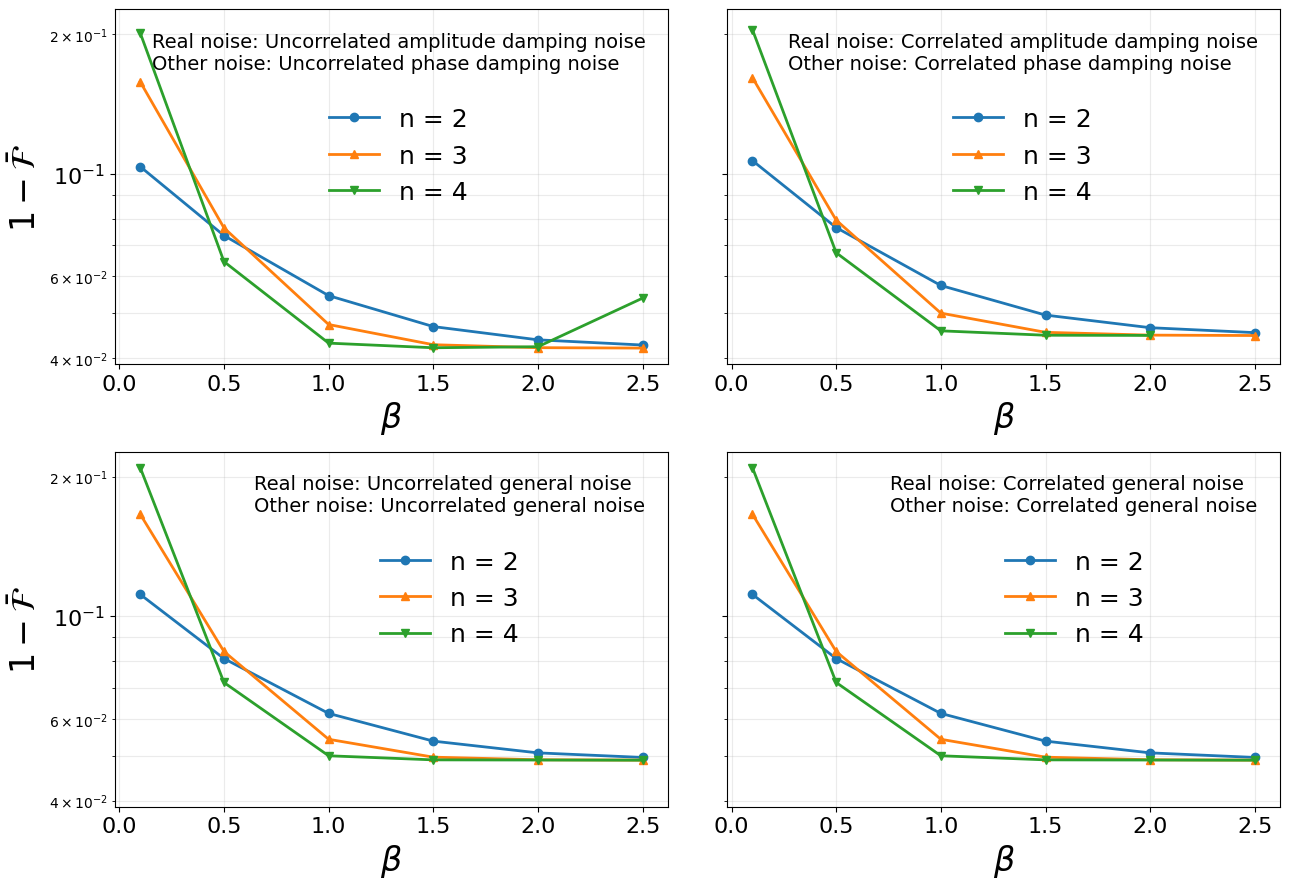

In [47]:
FOUR_PANEL_LAYOUT = [
    ["amplitude_damping", "phase_damping"],
    ["general", "general"],
]

fig_comparison, axes = plot_batch_grid(
    summary_df,
    layout=FOUR_PANEL_LAYOUT,
    log_scale=True,
)

fig_comparison.savefig(EXPERIMENTS_DIR / "comparison_grid_4panel.png", dpi=300)
fig_comparison.savefig(EXPERIMENTS_DIR / "comparison_grid_4panel.pdf", dpi=300)

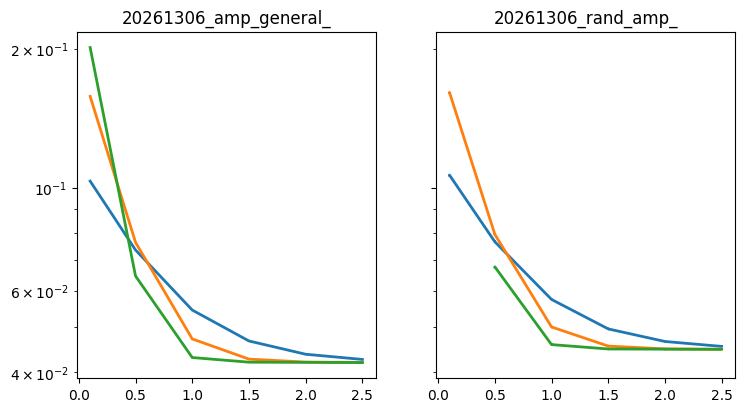

In [23]:
prepared = add_layout_columns(summary_df, batch_col="batch")
noise_1 = "general"
noise_2 = "amplitude_damping"
correlated = False
plot_frame = prepared.loc[
                (prepared["layout_noise_1"] == noise_1)
                & (prepared["layout_noise_2"] == noise_2)
                & (prepared["layout_correlation"] == correlated),
                ["name", "batch", "n_qubits", "beta", "infidelity"],
            ]

n_values = sorted(plot_frame["n_qubits"].unique().tolist())
batches = sorted(plot_frame["batch"].unique().tolist())

fig, axs = plt.subplots(1, len(batches), figsize=(8.5, 4.5), sharey=True)

for j, batch in enumerate(batches):
  batch_data = plot_frame.loc[plot_frame["batch"] == batch]
  batch_name = batch_data["batch"].iloc[0]
  for i, n_value in enumerate(n_values):
      subset = batch_data.loc[batch_data["n_qubits"] == n_value].sort_values("beta")
      axs[j].plot(
          subset["beta"],
          subset["infidelity"],
          linewidth=2,
          label=f"n = {n_value}",
      )
  axs[j].set_yscale("log")
  axs[j].set_title(batch_name)


## Check the General Noise Kraus Operators

In [51]:
df = summary_df[summary_df["name"].str.contains("rand")]
df

,name,n_qubits,beta,dt,n_timesteps,n_states,starting_state,recovery_type,collision_unitary,ancilla_state,...,csv_noise_1_name,csv_noise_2_name,config_path,config_exists,config_correlated_noise,config_real_noise,config_other_noise,config_noise_1_name,config_noise_2_name,other_noise
161,20261306_rand_amp_n2_b01,2,0.1,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,amplitude_damping,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,amplitude_damping,general,amplitude_damping,amplitude_damping
162,20261306_rand_amp_n2_b01,2,0.1,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,amplitude_damping,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,amplitude_damping,general,amplitude_damping,amplitude_damping
163,20261306_rand_amp_n2_b01,2,0.1,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,amplitude_damping,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,amplitude_damping,general,amplitude_damping,amplitude_damping
164,20261306_rand_amp_n2_b05,2,0.5,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,amplitude_damping,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,amplitude_damping,general,amplitude_damping,amplitude_damping
165,20261306_rand_amp_n2_b05,2,0.5,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,amplitude_damping,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,False,general,amplitude_damping,general,amplitude_damping,amplitude_damping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,20261306_rand_rand_corrn4_b05,4,0.5,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,general,general,general,general,general
277,20261306_rand_rand_corrn4_b10,4,1.0,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,general,general,general,general,general
278,20261306_rand_rand_corrn4_b15,4,1.5,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,general,general,general,general,general
279,20261306_rand_rand_corrn4_b20,4,2.0,0.031416,5,100,thermal,codespace,jc,ground_qubit,...,general,general,/home/fedesss/UNIPA/COLLISION_MODELS/shooting-...,True,True,general,general,general,general,general


In [55]:
for row in df.itertuples():
    experiment_dir = EXPERIMENTS_DIR / row.name
    config = read_config_metadata(EXPERIMENTS_DIR, row.name)
    if config["config_real_noise"] != "general" and config["config_other_noise"] != "general":
        print(f"Experiment {row.name} has unexpected noise configuration; skipping.")
        continue
    
